In [1]:
import pandas as pd
import seaborn as sns

In [ ]:
Unsupervised Learning:
    What is Clustering:
        working with unlabelled data  ----    to group the data or we need to cluster the data
 
Supervised Learning: -- we do have labelled data -- means, we have independent_variables(input_features) and Dependent_variable(Target_feature)    
    What is regression:
        working with labelled data  ---  to predict the continuous value

    What is classification:
        working with the categorical data -- to predict the categorical data
        
        
NLP or Computer Vision

In [ ]:
Problem Statement: or Use Case:   
        Hey, I want u to group the customers into their respective groups, which is having premium related information for one of our client

so many premiums available -- 


term policy  -- 50L insurance -- we need to pay 1.5L premium
                1Crore insurance -- we need to pay 2.7L premium
                1.5 cr insurance --- we need to pay around -- 4L
        
        
        
cust1 - salry - age- insurance which he took - area, working location,        
        
        
        
        

Senu slary - 50k   --- 50L   ----  if I give offer on 2cr -- can senu buy the premium-- he can't buy

if I give offer on 50L --- 1.4L is the premium -- can senu buy the premium -- He can buy

gangadhar salary - 1L  --- 1crore

Rajendra salary - 1.5L  -- 2cr      

In [2]:
df = pd.read_excel("EXL Shared Partner Data.xlsx")

In [3]:
df.head(2)

,Application_Nr,QuoteGeneratedDate,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Effective_Date,Paid_To_Date,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker
0,CUNA11261506,2018-02-07,15000,Void,13.75,Credit Card,Monthly,NaT,NaT,165.0,NaN,NaN,SI Term Band 1,53.0,Liberty
1,CUNA11263501,2018-02-08,10000,Signed,74.80,Credit Card,Monthly,2018-02-08,2022-09-08,897.6,897.6,PAC,SI Whole Life,70.0,Liberty


In [4]:
df.tail(2)

,Application_Nr,QuoteGeneratedDate,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Effective_Date,Paid_To_Date,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker
458870,CUNA17318525,2022-09-07,80000,Lapsed Abandoned,89.4,ACH/PAC,Monthly,NaT,NaT,1072.8,NaN,NaN,TAWL,32.0,Liberty
458871,CUNA17318599,2022-09-07,30000,Lapsed Abandoned,294.3,ACH/PAC,Monthly,NaT,NaT,3531.6,NaN,NaN,TAWL,NaN,Liberty


In [5]:
df.shape

(458872, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458872 entries, 0 to 458871
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Application_Nr       458862 non-null  object        
 1   QuoteGeneratedDate   458872 non-null  datetime64[ns]
 2   OfferCoverageAmount  458872 non-null  int64         
 3   Offer_Stat_Desc      458872 non-null  object        
 4   OfferPremiumAmount   458872 non-null  float64       
 5   OfferBillingMethod   458872 non-null  object        
 6   Pmnt_Freq_Desc       458832 non-null  object        
 7   Effective_Date       190605 non-null  datetime64[ns]
 8   Paid_To_Date         190605 non-null  datetime64[ns]
 9   Offered_NAP          458872 non-null  float64       
 10  Issued_NAP           190605 non-null  float64       
 11  CurrentBillMethod    190605 non-null  object        
 12  ProductType          458862 non-null  object        
 13  Age_at_AppRece

In [7]:
from datetime import datetime
df['Quote_Year_month'] = df['QuoteGeneratedDate'].apply(lambda x: datetime.strftime(x, '%Y-%m'))

In [8]:
df['Quote_Year'] = df['QuoteGeneratedDate'].apply(lambda x: datetime.strftime(x, '%Y'))

In [9]:
df.head(2)

,Application_Nr,QuoteGeneratedDate,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Effective_Date,Paid_To_Date,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker,Quote_Year_month,Quote_Year
0,CUNA11261506,2018-02-07,15000,Void,13.75,Credit Card,Monthly,NaT,NaT,165.0,NaN,NaN,SI Term Band 1,53.0,Liberty,2018-02,2018
1,CUNA11263501,2018-02-08,10000,Signed,74.80,Credit Card,Monthly,2018-02-08,2022-09-08,897.6,897.6,PAC,SI Whole Life,70.0,Liberty,2018-02,2018


In [10]:
data = df.groupby(['Quote_Year'])['OfferCoverageAmount'].sum().reset_index(name="coverage_sum")

In [11]:
data_month = df.groupby(['Quote_Year_month'])['OfferCoverageAmount'].sum().reset_index(name="coverage_sum")

In [12]:
data_month.head()

,Quote_Year_month,coverage_sum
0,2018-02,3379000
1,2018-03,7988000
2,2018-04,6284000
3,2018-05,6705000
4,2018-06,6586000


In [13]:
data_month.shape

(56, 2)

In [14]:
data.head(2)

,Quote_Year,coverage_sum
0,2018,179392000
1,2019,1096232000


In [15]:
data

,Quote_Year,coverage_sum
0,2018,179392000
1,2019,1096232000
2,2020,2505178000
3,2021,7213646000
4,2022,8146486000


In [16]:
data.shape

(5, 2)

C:\Users\gn221m\Anaconda3\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='Quote_Year_month', ylabel='coverage_sum'>

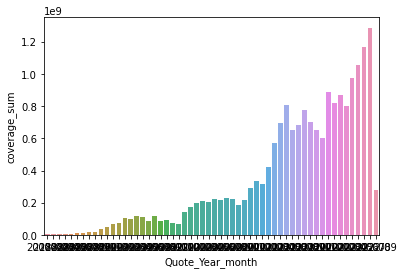

In [17]:
sns.barplot(data_month['Quote_Year_month'], data_month['coverage_sum'])

In [18]:
data = df.groupby(['Quote_Year'])['OfferCoverageAmount'].sum().reset_index(name="coverage_sum")

In [19]:
df.head()

,Application_Nr,QuoteGeneratedDate,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Effective_Date,Paid_To_Date,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker,Quote_Year_month,Quote_Year
0,CUNA11261506,2018-02-07,15000,Void,13.75,Credit Card,Monthly,NaT,NaT,165.0,NaN,NaN,SI Term Band 1,53.0,Liberty,2018-02,2018
1,CUNA11263501,2018-02-08,10000,Signed,74.80,Credit Card,Monthly,2018-02-08,2022-09-08,897.6,897.6,PAC,SI Whole Life,70.0,Liberty,2018-02,2018
2,CUNA11264400,2018-02-09,15000,Signed,42.35,Credit Card,Monthly,2018-02-09,2022-10-09,508.2,508.2,DIR,SI Whole Life,54.0,Liberty,2018-02,2018
3,CUNA11264436,2018-02-09,15000,Signed,57.05,Credit Card,Monthly,2018-02-09,2022-10-09,684.6,684.6,DIR,SI Whole Life,58.0,Liberty,2018-02,2018
4,CUNA11264525,2018-02-09,10000,Signed,27.80,ACH/PAC,Monthly,2018-02-12,2021-02-12,333.6,333.6,PAC,SI Term Band 1,65.0,Liberty,2018-02,2018


In [20]:
data.shape

(5, 2)

In [21]:
data.head()

,Quote_Year,coverage_sum
0,2018,179392000
1,2019,1096232000
2,2020,2505178000
3,2021,7213646000
4,2022,8146486000


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458872 entries, 0 to 458871
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Application_Nr       458862 non-null  object        
 1   QuoteGeneratedDate   458872 non-null  datetime64[ns]
 2   OfferCoverageAmount  458872 non-null  int64         
 3   Offer_Stat_Desc      458872 non-null  object        
 4   OfferPremiumAmount   458872 non-null  float64       
 5   OfferBillingMethod   458872 non-null  object        
 6   Pmnt_Freq_Desc       458832 non-null  object        
 7   Effective_Date       190605 non-null  datetime64[ns]
 8   Paid_To_Date         190605 non-null  datetime64[ns]
 9   Offered_NAP          458872 non-null  float64       
 10  Issued_NAP           190605 non-null  float64       
 11  CurrentBillMethod    190605 non-null  object        
 12  ProductType          458862 non-null  object        
 13  Age_at_AppRece

In [23]:
df.isna().sum()

Application_Nr             10
QuoteGeneratedDate          0
OfferCoverageAmount         0
Offer_Stat_Desc             0
OfferPremiumAmount          0
OfferBillingMethod          0
Pmnt_Freq_Desc             40
Effective_Date         268267
Paid_To_Date           268267
Offered_NAP                 0
Issued_NAP             268267
CurrentBillMethod      268267
ProductType                10
Age_at_AppReceived      58245
PartnerMarker               0
Quote_Year_month            0
Quote_Year                  0
dtype: int64

In [24]:
df = df.dropna(subset=['Application_Nr'])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 458862 entries, 0 to 458871
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Application_Nr       458862 non-null  object        
 1   QuoteGeneratedDate   458862 non-null  datetime64[ns]
 2   OfferCoverageAmount  458862 non-null  int64         
 3   Offer_Stat_Desc      458862 non-null  object        
 4   OfferPremiumAmount   458862 non-null  float64       
 5   OfferBillingMethod   458862 non-null  object        
 6   Pmnt_Freq_Desc       458822 non-null  object        
 7   Effective_Date       190605 non-null  datetime64[ns]
 8   Paid_To_Date         190605 non-null  datetime64[ns]
 9   Offered_NAP          458862 non-null  float64       
 10  Issued_NAP           190605 non-null  float64       
 11  CurrentBillMethod    190605 non-null  object        
 12  ProductType          458852 non-null  object        
 13  Age_at_AppRece

In [26]:
df.columns

Index(['Application_Nr', 'QuoteGeneratedDate', 'OfferCoverageAmount',
       'Offer_Stat_Desc', 'OfferPremiumAmount', 'OfferBillingMethod',
       'Pmnt_Freq_Desc', 'Effective_Date', 'Paid_To_Date', 'Offered_NAP',
       'Issued_NAP', 'CurrentBillMethod', 'ProductType', 'Age_at_AppReceived',
       'PartnerMarker', 'Quote_Year_month', 'Quote_Year'],
      dtype='object')

In [27]:
df.head(2)

,Application_Nr,QuoteGeneratedDate,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Effective_Date,Paid_To_Date,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker,Quote_Year_month,Quote_Year
0,CUNA11261506,2018-02-07,15000,Void,13.75,Credit Card,Monthly,NaT,NaT,165.0,NaN,NaN,SI Term Band 1,53.0,Liberty,2018-02,2018
1,CUNA11263501,2018-02-08,10000,Signed,74.80,Credit Card,Monthly,2018-02-08,2022-09-08,897.6,897.6,PAC,SI Whole Life,70.0,Liberty,2018-02,2018


In [28]:
#df['Application_Nr'].value_counts()

In [29]:
df = df[['OfferCoverageAmount','Offer_Stat_Desc', 'OfferPremiumAmount', 'OfferBillingMethod',
       'Pmnt_Freq_Desc','Offered_NAP','Issued_NAP', 'CurrentBillMethod', 'ProductType', 'Age_at_AppReceived',
       'PartnerMarker']]

In [ ]:
5L rows of daat --- 2.5L rows is having null values --- is it recommended to remove null values data

if we remove 2.5L -- data loss will be there

null values we can fill with either mean, median,mode or any specific value(will come with domain knowledge)

if u have continuous data - we can fill with either mean or median or any specific value

If u have categorical data - we can fill with mode or any specific value

In [30]:
df.isna().sum()

OfferCoverageAmount         0
Offer_Stat_Desc             0
OfferPremiumAmount          0
OfferBillingMethod          0
Pmnt_Freq_Desc             40
Offered_NAP                 0
Issued_NAP             268257
CurrentBillMethod      268257
ProductType                10
Age_at_AppReceived      58235
PartnerMarker               0
dtype: int64

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 458862 entries, 0 to 458871
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   OfferCoverageAmount  458862 non-null  int64  
 1   Offer_Stat_Desc      458862 non-null  object 
 2   OfferPremiumAmount   458862 non-null  float64
 3   OfferBillingMethod   458862 non-null  object 
 4   Pmnt_Freq_Desc       458822 non-null  object 
 5   Offered_NAP          458862 non-null  float64
 6   Issued_NAP           190605 non-null  float64
 7   CurrentBillMethod    190605 non-null  object 
 8   ProductType          458852 non-null  object 
 9   Age_at_AppReceived   400627 non-null  float64
 10  PartnerMarker        458862 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 42.0+ MB


In [32]:
#data = df.dropna()

In [33]:
data.isna().sum()

Quote_Year      0
coverage_sum    0
dtype: int64

In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Quote_Year    5 non-null      object
 1   coverage_sum  5 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 208.0+ bytes


In [35]:
def null_values(base_dataset):
    print(base_dataset.isna().sum())
    len(base_dataset.isna().sum().index)
    cont=base_dataset.describe().columns
    print(cont)
    # fetching all column names form from dataframe and trying to filter out some of the column names which we are getting from the base_dataset.describe()
    cat=[i for i in base_dataset.columns if i not in base_dataset.describe().columns] # this is one way of getting categorical column
    # we do have other ways also to get categorical columns
    
    print(cat)
    for i in cat:
        base_dataset[i].fillna(base_dataset[i].value_counts().index[0],inplace=True)
        # fill these null values with the help of mode also
    for i in cont:
        base_dataset[i].fillna(base_dataset[i].median(),inplace=True)
    print(base_dataset.isna().sum())
    return base_dataset,cat,cont

In [36]:
data_cleaned,cat,cont = null_values(df)

OfferCoverageAmount         0
Offer_Stat_Desc             0
OfferPremiumAmount          0
OfferBillingMethod          0
Pmnt_Freq_Desc             40
Offered_NAP                 0
Issued_NAP             268257
CurrentBillMethod      268257
ProductType                10
Age_at_AppReceived      58235
PartnerMarker               0
dtype: int64
Index(['OfferCoverageAmount', 'OfferPremiumAmount', 'Offered_NAP',
       'Issued_NAP', 'Age_at_AppReceived'],
      dtype='object')
['Offer_Stat_Desc', 'OfferBillingMethod', 'Pmnt_Freq_Desc', 'CurrentBillMethod', 'ProductType', 'PartnerMarker']
OfferCoverageAmount    0
Offer_Stat_Desc        0
OfferPremiumAmount     0
OfferBillingMethod     0
Pmnt_Freq_Desc         0
Offered_NAP            0
Issued_NAP             0
CurrentBillMethod      0
ProductType            0
Age_at_AppReceived     0
PartnerMarker          0
dtype: int64


In [37]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 458862 entries, 0 to 458871
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   OfferCoverageAmount  458862 non-null  int64  
 1   Offer_Stat_Desc      458862 non-null  object 
 2   OfferPremiumAmount   458862 non-null  float64
 3   OfferBillingMethod   458862 non-null  object 
 4   Pmnt_Freq_Desc       458862 non-null  object 
 5   Offered_NAP          458862 non-null  float64
 6   Issued_NAP           458862 non-null  float64
 7   CurrentBillMethod    458862 non-null  object 
 8   ProductType          458862 non-null  object 
 9   Age_at_AppReceived   458862 non-null  float64
 10  PartnerMarker        458862 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 42.0+ MB


In [38]:
cat

['Offer_Stat_Desc',
 'OfferBillingMethod',
 'Pmnt_Freq_Desc',
 'CurrentBillMethod',
 'ProductType',
 'PartnerMarker']

In [39]:
cont

Index(['OfferCoverageAmount', 'OfferPremiumAmount', 'Offered_NAP',
       'Issued_NAP', 'Age_at_AppReceived'],
      dtype='object')

In [40]:
data_cleaned.head(2)

,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker
0,15000,Void,13.75,Credit Card,Monthly,165.0,682.68,DIR,SI Term Band 1,53.0,Liberty
1,10000,Signed,74.80,Credit Card,Monthly,897.6,897.60,PAC,SI Whole Life,70.0,Liberty


In [ ]:
Label Encoder Or Onehot Encoder 


what is the diff between Label Encoder and Onehot Encoder
Label Encoder -- ['Credit Card', 'ACH/PAC', 'Direct Bill', 'List Bill', 'Unknown']  -- 0,1,2,3,4
                           1         0          2             3             4
    
Onehot Enoder or pandas get dummies -- 'OfferBillingMethod_ACH/PAC', 'OfferBillingMethod_Credit Card', 'OfferBillingMethod_Direct Bill','OfferBillingMethod_List Bill', 'OfferBillingMethod_Unknown'

                    0                                     0                                   1                                   0                               0
    
    
df_upd =  pd.get_dummies(df)

In [41]:
from sklearn.preprocessing import LabelEncoder
def label_encoders(data):
    cat_columns=[i for i in data.columns if i not in data.describe().columns]
    le=LabelEncoder()
    for i in cat_columns:
        le.fit(data[i])
        x=le.transform(data[i])
        data[i]=x
    return data

In [42]:
data_cleaned['OfferBillingMethod'].unique()

array(['Credit Card', 'ACH/PAC', 'Direct Bill', 'List Bill', 'Unknown'],
      dtype=object)

In [43]:
base_data_label_encoded=label_encoders(data_cleaned)

In [60]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=10).fit(base_data_label_encoded)

In [61]:
labels=kmeans.labels_

In [62]:
labels

array([1, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0])

In [52]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=10, random_state=10).fit(base_data_label_encoded)

KeyboardInterrupt: 

In [53]:
labels=kmeans.labels_

In [54]:
labels

array([7, 2, 7, ..., 8, 9, 5])

In [55]:
val=pd.DataFrame(data=labels,columns=['sample'])

In [56]:
val['sample'].value_counts()

2    166365
7     98432
5     70002
0     49810
4     29654
3     12272
6     10836
9      9578
1      6804
8      5109
Name: sample, dtype: int64

In [57]:
base_data_label_encoded['cluster']=labels

In [58]:
base_data_label_encoded['cluster'].value_counts()

In [59]:
base_data_label_encoded.head(2)

,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker
0,15000,17,13.75,1,1,165.0,682.68,1,1,53.0,4
1,10000,14,74.80,1,1,897.6,897.60,2,3,70.0,4


In [60]:
# WCSS -> Within Clusters Sum of Squares
# finding wcss value for different number of clusters

wcss = []

for i in range(2,10): #from 2 to 10
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=10)
    kmeans.fit(base_data_label_encoded)

    wcss.append(kmeans.inertia_)

In [ ]:

2 clusters -- wcss value - 1.50
3 clusters -- wcss value -- 0.75
4 =-- 0.5  -- we are trying divide the data into 4 clusters
5 --- 0.25
6 -- 0.20 --- optimal number of clusters as 6
7 -- 0.20
8- 0.20

20 clusters -- wcss value

In [61]:
import matplotlib.pyplot as plt

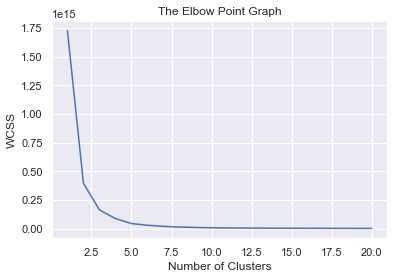

In [62]:
# plot an elbow graph

sns.set()
plt.plot(range(2,10), wcss)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

##### from the above Elbow graph we can say that the optimal number of clusters are 5, so we r fitting the model with 5 clusters

We now determine the optimal number of clusters using a mathematical technique. Here, We will use the Silhouette Scores for the purpose.

**What is Silhouette Score?**

Silhouette Coefficient or silhouette score is a metric used to calculate the goodness of a clustering technique. Its value ranges from -1 to 1.

1: Means clusters are well apart from each other and clearly distinguished.

0: Means clusters are indifferent, or we can say that the distance between clusters is not significant.

-1: Means clusters are assigned in the wrong way.


Silhouette Score = (b-a)/max(a,b)

where

Mean distance between the observation and all other data points in the same cluster. This distance can also be called a mean intra-cluster distance. The mean distance is denoted by a

Mean distance between the observation and all other data points of the next nearest cluster. This distance can also be called a mean nearest-cluster distance. The mean distance is denoted by b

In [64]:
from sklearn.metrics import silhouette_score

In [ ]:
silhouette_scores = []

for i in range(2,5):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=10)
    #kmeans.fit_predict(base_data_label_encoded)
    silhouette_scores.append(silhouette_score(base_data_label_encoded, kmeans.fit_predict(base_data_label_encoded)))
    #silhouette_scores.append(kmeans.inertia_)
    print("one loop completed")

In [ ]:
# Plotting a bar graph to compare the results
plt.bar(range(2,11), silhouette_scores)
plt.xlabel('Number of clusters', fontsize = 20)
plt.ylabel('silhouette_score', fontsize = 20)
plt.show()

##### Thus, with the help of the silhouette scores, it is concluded that the optimal number of clusters for the given data and clustering technique is 3.

In [70]:
kmeans = KMeans(n_clusters=5, random_state=10).fit(base_data_label_encoded)

In [71]:
labels=kmeans.labels_

In [72]:
print(labels)

[0 0 0 ... 1 2 0]


In [73]:
val=pd.DataFrame(data=labels,columns=['sample'])

In [74]:
val['sample'].value_counts()

0    331014
3     57658
2     35199
4     18498
1     16493
Name: sample, dtype: int64

In [75]:
base_data_label_encoded['cluster']=labels

In [76]:
base_data_label_encoded['cluster'].value_counts()

0    331014
3     57658
2     35199
4     18498
1     16493
Name: cluster, dtype: int64

In [77]:
base_data_label_encoded.head(2)

,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker,cluster
0,15000,17,13.75,1,1,165.0,682.68,1,1,53.0,4,0
1,10000,14,74.80,1,1,897.6,897.60,2,3,70.0,4,0


In [100]:
X = base_data_label_encoded[['OfferCoverageAmount','OfferPremiumAmount']]

In [104]:
X

,OfferCoverageAmount,OfferPremiumAmount
0,15000,13.75
1,10000,74.80
2,15000,42.35
3,15000,57.05
4,10000,27.80
...,...,...
458867,70000,186.60
458868,300000,68.00
458869,250000,55.00
458870,80000,89.40


In [105]:
X = X.values

In [106]:
X

array([[1.500e+04, 1.375e+01],
       [1.000e+04, 7.480e+01],
       [1.500e+04, 4.235e+01],
       ...,
       [2.500e+05, 5.500e+01],
       [8.000e+04, 8.940e+01],
       [3.000e+04, 2.943e+02]])

In [102]:
Y = labels

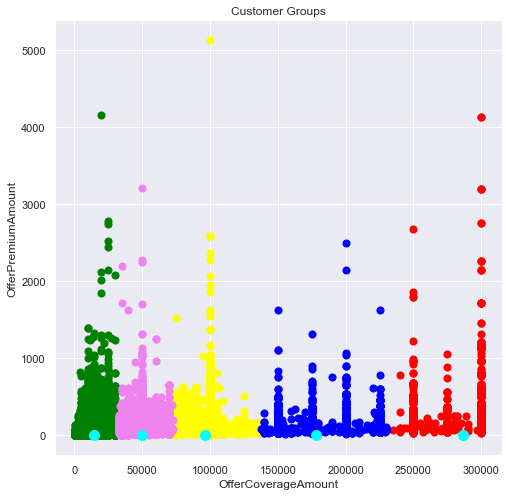

In [107]:
# plotting all the clusters and their Centroids

plt.figure(figsize=(8,8))
plt.scatter(X[Y==0,0], X[Y==0,1], s=50, c='green', label='Cluster 1')
plt.scatter(X[Y==1,0], X[Y==1,1], s=50, c='red', label='Cluster 2')
plt.scatter(X[Y==2,0], X[Y==2,1], s=50, c='yellow', label='Cluster 3')
plt.scatter(X[Y==3,0], X[Y==3,1], s=50, c='violet', label='Cluster 4')
plt.scatter(X[Y==4,0], X[Y==4,1], s=50, c='blue', label='Cluster 5')

# plot the centroids
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='cyan', label='Centroids')

plt.title('Customer Groups')
plt.xlabel('OfferCoverageAmount')
plt.ylabel('OfferPremiumAmount')
plt.show()

In [ ]:
# Apply the standardisation and re run the clustering code and find the optimal no of clusters

In [ ]:
# Evaluating the different models and Visualizing the results.

k = [2, 3, 4, 5, 6,7]
  
# Appending the silhouette scores of the different models to the list
silhouette_scores = []
silhouette_scores.append(
        silhouette_score(X_principal, ac2.fit_predict(X_principal)))
silhouette_scores.append(
        silhouette_score(X_principal, ac3.fit_predict(X_principal)))
silhouette_scores.append(
        silhouette_score(X_principal, ac4.fit_predict(X_principal)))
silhouette_scores.append(
        silhouette_score(X_principal, ac5.fit_predict(X_principal)))
silhouette_scores.append(
        silhouette_score(X_principal, ac6.fit_predict(X_principal)))
silhouette_scores.append(
        silhouette_score(X_principal, ac7.fit_predict(X_principal)))

In [ ]:
Interview Qn:Do we have any metrics to identify how well the data got clusted in Unsupervised learning

In [ ]:
What is the difference between k-means algorithm and Agglomerative algorithm and DBSCAn Algorithm